# COMP3610 Assignment 2

- **Name:** Sonali Maharaj
- **Student ID:** 816034459
- **Course:** COMP3610  
- **Assignment:** Assignment 3

---

In [1]:
!pip install pyspark

# Part 1: Distributed Data Processing with Spark

## Task 1.1: Spark Environment Setup & Data Loading

In this task, I will initialize a SparkSession with appropriate configuration settings, load the NYC Yellow Taxi January 2024 Parquet dataset into a Spark DataFrame, and inspect its schema. I will also report the total row count and number of partitions, then compare Spark load time with Pandas load time for the same file.

Imports

In [2]:
import time
import pandas as pd

from pyspark.sql import SparkSession

Data Sources

In [3]:
# Data sources
trip_data_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
lookup_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

Downloading

In [4]:
import os
import urllib.request

os.makedirs("data", exist_ok=True)

trip_data_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
lookup_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

trip_data_path = "data/yellow_tripdata_2024-01.parquet"
lookup_path = "data/taxi_zone_lookup.csv"

if not os.path.exists(trip_data_path):
    urllib.request.urlretrieve(trip_data_url, trip_data_path)

if not os.path.exists(lookup_path):
    urllib.request.urlretrieve(lookup_url, lookup_path)

print("Files downloaded successfully.")

Files downloaded successfully.


Creating SparkSession

In [5]:
spark = (
    SparkSession.builder
    .appName("COMP3610_NYC_Taxi_Distributed_Analytics")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Adaptive Query Execution:", spark.conf.get("spark.sql.adaptive.enabled"))
print("Driver memory:", spark.conf.get("spark.driver.memory"))
print("Executor memory:", spark.conf.get("spark.executor.memory"))

Spark version: 4.0.2
Adaptive Query Execution: true
Driver memory: 4g
Executor memory: 4g


Spark load timing

In [6]:
start_spark = time.time()
taxi_spark_df = spark.read.parquet(trip_data_path)
spark_load_time = time.time() - start_spark

Displaying schema and verifying column types

In [7]:
print("Taxi DataFrame schema:")
taxi_spark_df.printSchema()

Taxi DataFrame schema:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



Row count and partition count

In [8]:
row_count = taxi_spark_df.count()
partition_count = taxi_spark_df.rdd.getNumPartitions()

print(f"Total row count: {row_count:,}")
print(f"Number of partitions: {partition_count}")

Total row count: 2,964,624
Number of partitions: 2


Pandas load timing

In [9]:
start_pandas = time.time()
taxi_pandas_df = pd.read_parquet(trip_data_path)
pandas_load_time = time.time() - start_pandas

print(f"Pandas load time: {pandas_load_time:.2f} seconds")

Pandas load time: 3.29 seconds


Comparing timings

In [10]:
print("\nLoad Time Comparison")
print(f"Spark load time : {spark_load_time:.2f} seconds")
print(f"Pandas load time: {pandas_load_time:.2f} seconds")

if spark_load_time < pandas_load_time:
    print("Spark loaded the file faster than Pandas in this run.")
elif pandas_load_time < spark_load_time:
    print("Pandas loaded the file faster than Spark in this run.")
else:
    print("Spark and Pandas had similar load times in this run.")


Load Time Comparison
Spark load time : 6.30 seconds
Pandas load time: 3.29 seconds
Pandas loaded the file faster than Spark in this run.


### Interpretation

The dataset was successfully loaded into both Spark and Pandas. In this case, Pandas loaded the data faster than Spark due to lower overhead, as Spark requires initializing a distributed computing environment. However, Spark is more suitable for large-scale data processing because it can handle much larger datasets and perform parallel computations efficiently, which becomes advantageous in later stages of analysis.

## Task 1.2: Data Cleaning & Feature Engineering in Spark

In this task, I will clean the NYC Yellow Taxi dataset using the Spark DataFrame API by removing rows with null values in critical columns and filtering out invalid trips. I will then create derived features for trip duration, trip speed, pickup hour, pickup day of week, and tip percentage using Spark functions. To document the cleaning process, I will report the number of rows removed at each step.

Imports

In [11]:
from pyspark.sql import functions as F

Keep needed columns

In [12]:
taxi_df = taxi_spark_df.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
)

Count starting rows

In [13]:
initial_count = taxi_df.count()
print(f"Initial row count: {initial_count:,}")

Initial row count: 2,964,624


Remove nulls in critical columns

In [14]:
critical_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "trip_distance"
]

df_no_nulls = taxi_df.dropna(subset=critical_columns)

after_null_removal = df_no_nulls.count()
nulls_removed = initial_count - after_null_removal

print(f"Rows after null removal: {after_null_removal:,}")
print(f"Rows removed due to nulls: {nulls_removed:,}")

Rows after null removal: 2,964,624
Rows removed due to nulls: 0


Filter invalid trips

In [15]:
# 1) Remove zero or negative trip distance
df_positive_distance = df_no_nulls.filter(F.col("trip_distance") > 0)

after_distance_filter = df_positive_distance.count()
distance_removed = after_null_removal - after_distance_filter

print(f"Rows after distance filter: {after_distance_filter:,}")
print(f"Rows removed due to zero/negative distance: {distance_removed:,}")

Rows after distance filter: 2,904,253
Rows removed due to zero/negative distance: 60,371


Additional invalid-trip filtering

This step removes rows with negative fare values so invalid pricing does not distort downstream averages and tip metrics.

In [16]:
# 2) Remove negative fares
df_nonnegative_fare = df_positive_distance.filter(F.col("fare_amount") >= 0)

after_negative_fare_filter = df_nonnegative_fare.count()
negative_fare_removed = after_distance_filter - after_negative_fare_filter

print(f"Rows after negative fare filter: {after_negative_fare_filter:,}")
print(f"Rows removed due to negative fares: {negative_fare_removed:,}")

Rows after negative fare filter: 2,870,188
Rows removed due to negative fares: 34,065


Outlier fare filtering

This filter removes extremely large fare outliers (greater than 500) to reduce skew in aggregated statistics.

In [17]:
# 3) Remove fares greater than $500
df_reasonable_fare = df_nonnegative_fare.filter(F.col("fare_amount") <= 500)

after_high_fare_filter = df_reasonable_fare.count()
high_fare_removed = after_negative_fare_filter - after_high_fare_filter

print(f"Rows after high fare filter: {after_high_fare_filter:,}")
print(f"Rows removed due to fares > $500: {high_fare_removed:,}")

Rows after high fare filter: 2,870,158
Rows removed due to fares > $500: 30


Temporal consistency filtering

This step removes rows where dropoff occurs before pickup, which indicates invalid timestamp sequencing.

In [18]:
# 4) Remove trips where dropoff is before pickup
df_valid_time = df_reasonable_fare.filter(
    F.col("tpep_dropoff_datetime") >= F.col("tpep_pickup_datetime")
)

after_time_filter = df_valid_time.count()
time_removed = after_high_fare_filter - after_time_filter

print(f"Rows after time filter: {after_time_filter:,}")
print(f"Rows removed due to dropoff before pickup: {time_removed:,}")

Rows after time filter: 2,870,102
Rows removed due to dropoff before pickup: 56


Create derived columns

In [19]:
taxi_cleaned = (
    df_valid_time
    .withColumn(
        "trip_duration_minutes",
        F.round(
            (
                F.unix_timestamp("tpep_dropoff_datetime")
                - F.unix_timestamp("tpep_pickup_datetime")
            ) / 60.0,
            2
        )
    )
    .withColumn(
        "trip_speed_mph",
        F.round(
            F.when(
                F.col("trip_duration_minutes") > 0,
                F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0)
            ).otherwise(None),
            2
        )
    )
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_day_of_week", F.dayofweek("tpep_pickup_datetime"))
    .withColumn(
        "tip_percentage",
        F.round(
            F.when(
                F.col("fare_amount") > 0,
                (F.col("tip_amount") / F.col("fare_amount")) * 100.0
            ).otherwise(None),
            2
        )
    )
)

trips_enriched = taxi_cleaned

Final row count and preview

In [20]:
final_count = taxi_cleaned.count()
total_removed = initial_count - final_count

print(f"Final cleaned row count: {final_count:,}")
print(f"Total rows removed: {total_removed:,}")

taxi_cleaned.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "trip_duration_minutes",
    "trip_speed_mph",
    "pickup_hour",
    "pickup_day_of_week",
    "tip_percentage"
).show(5, truncate=False)

Final cleaned row count: 2,870,102
Total rows removed: 94,522
+--------------------+---------------------+-------------+-----------+----------+---------------------+--------------+-----------+------------------+--------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|fare_amount|tip_amount|trip_duration_minutes|trip_speed_mph|pickup_hour|pickup_day_of_week|tip_percentage|
+--------------------+---------------------+-------------+-----------+----------+---------------------+--------------+-----------+------------------+--------------+
|2024-01-01 00:57:55 |2024-01-01 01:17:43  |1.72         |17.7       |0.0       |19.8                 |5.21          |0          |2                 |0.0           |
|2024-01-01 00:03:00 |2024-01-01 00:09:36  |1.8          |10.0       |3.75      |6.6                  |16.36         |0          |2                 |37.5          |
|2024-01-01 00:17:06 |2024-01-01 00:35:01  |4.7          |23.3       |3.0       |17.92                |15.74     

Cleaning audit output

This cell prints the cleaning summary so each filtering stage is transparent and reproducible.

In [21]:
print("Cleaning Summary")
print(f"Initial rows: {initial_count:,}")
print(f"Removed null rows: {nulls_removed:,}")
print(f"Removed zero/negative distance rows: {distance_removed:,}")
print(f"Removed negative fare rows: {negative_fare_removed:,}")
print(f"Removed fare > $500 rows: {high_fare_removed:,}")
print(f"Removed dropoff before pickup rows: {time_removed:,}")
print(f"Final cleaned rows: {final_count:,}")

Cleaning Summary
Initial rows: 2,964,624
Removed null rows: 0
Removed zero/negative distance rows: 60,371
Removed negative fare rows: 34,065
Removed fare > $500 rows: 30
Removed dropoff before pickup rows: 56
Final cleaned rows: 2,870,102


In this section, we began with 2,964,624 rows. We cleaned the dataset by removing null rows, zero/negative distance rows, negative fare rows, fare > $500 rows and rows where the dropoff time was before the pickup time. So, at the end we remain with 2,870,102 rows which allow us to gain valuable insights since we removed the rows which contained invalid data.

## Task 1.3: Spark SQL Analytics

In this task, I will register the cleaned and enriched taxi dataset as a temporary SQL view and use Spark SQL to answer analytical questions about trip patterns, revenue, and tipping behavior.

I will collect publicly available PDFs related to NYC taxi policy, extract text using PyPDF/LangChain document loaders, and report relevant statistics and quality issues.

In [22]:
trips_enriched.createOrReplaceTempView("taxi_trips")
print("Temporary view 'taxi_trips' created successfully.")

Temporary view 'taxi_trips' created successfully.


### Query 1: Top 10 busiest pickup hours

In [23]:
query1 = """
SELECT
    pickup_hour,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 10
"""

q1_result = spark.sql(query1)
q1_result.show(truncate=False)

+-----------+----------+--------+------------------+
|pickup_hour|trip_count|avg_fare|avg_tip_percentage|
+-----------+----------+--------+------------------+
|18         |206284    |17.01   |22.78             |
|17         |200315    |18.12   |22.34             |
|16         |184971    |19.46   |21.84             |
|15         |184009    |19.11   |19.8              |
|19         |178812    |17.63   |22.86             |
|14         |178031    |19.27   |19.8              |
|13         |165361    |18.42   |19.79             |
|12         |159916    |17.8    |19.74             |
|21         |155915    |18.29   |21.88             |
|20         |155561    |18.05   |22.17             |
+-----------+----------+--------+------------------+



The busiest pickup hours occur during the late afternoon and early evening (around 16:00–19:00), indicating peak taxi demand during commute hours. These periods also show relatively high average fares and tip percentages, suggesting that increased demand is associated with higher spending and consistent tipping behavior.

### Query 2: Day of week with highest average trip speed

In [24]:
query2 = """
SELECT
    pickup_day_of_week,
    ROUND(AVG(trip_speed_mph), 2) AS avg_trip_speed_mph,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_trip_duration_minutes
FROM taxi_trips
WHERE trip_speed_mph IS NOT NULL
GROUP BY pickup_day_of_week
ORDER BY avg_trip_speed_mph DESC
"""

q2_result = spark.sql(query2)
q2_result.show(truncate=False)

+------------------+------------------+-----------------+-------------------------+
|pickup_day_of_week|avg_trip_speed_mph|avg_trip_distance|avg_trip_duration_minutes|
+------------------+------------------+-----------------+-------------------------+
|3                 |17.45             |4.25             |16.18                    |
|1                 |15.99             |3.9              |14.32                    |
|2                 |13.84             |3.77             |15.85                    |
|6                 |13.4              |3.68             |15.93                    |
|7                 |13.28             |3.39             |14.9                     |
|5                 |12.47             |3.54             |16.43                    |
|4                 |12.38             |3.61             |16.26                    |
+------------------+------------------+-----------------+-------------------------+



The highest average trip speed occurs on day 3 (Tuesday), suggesting relatively lighter traffic conditions compared to other days. This day also has slightly longer average trip distances with moderate durations, indicating more efficient travel and less congestion.

### Query 3: Top 5 pickup locations by total revenue for each day of week

In [25]:
lookup_df = spark.read.csv(lookup_path, header=True, inferSchema=True)
lookup_df.createOrReplaceTempView("taxi_lookup")

Query 3 SQL definition

This query uses a window function to rank top pickup locations by total revenue within each day-of-week partition.

In [26]:
query3 = """
WITH location_revenue AS (
    SELECT
        pickup_day_of_week,
        PULocationID,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM taxi_trips
    GROUP BY pickup_day_of_week, PULocationID
),
ranked_locations AS (
    SELECT
        pickup_day_of_week,
        PULocationID,
        total_revenue,
        ROW_NUMBER() OVER (
            PARTITION BY pickup_day_of_week
            ORDER BY total_revenue DESC
        ) AS revenue_rank
    FROM location_revenue
)
SELECT
    r.pickup_day_of_week,
    r.PULocationID,
    l.Zone AS pickup_zone,
    l.Borough AS pickup_borough,
    r.total_revenue,
    r.revenue_rank
FROM ranked_locations r
LEFT JOIN taxi_lookup l
    ON r.PULocationID = l.LocationID
WHERE r.revenue_rank <= 5
ORDER BY r.pickup_day_of_week, r.revenue_rank
"""



Query 3 execution

This cell executes the ranking query and displays results for interpretation and verification.

In [27]:
q3_result = spark.sql(query3)
q3_result.show(35, truncate=False)

+------------------+------------+----------------------------+--------------+-------------+------------+
|pickup_day_of_week|PULocationID|pickup_zone                 |pickup_borough|total_revenue|revenue_rank|
+------------------+------------+----------------------------+--------------+-------------+------------+
|1                 |132         |JFK Airport                 |Queens        |1564287.93   |1           |
|1                 |138         |LaGuardia Airport           |Queens        |763398.54    |2           |
|1                 |230         |Times Sq/Theatre District   |Manhattan     |346553.95    |3           |
|1                 |186         |Penn Station/Madison Sq West|Manhattan     |264131.38    |4           |
|1                 |79          |East Village                |Manhattan     |263467.74    |5           |
|2                 |132         |JFK Airport                 |Queens        |2054606.73   |1           |
|2                 |138         |LaGuardia Airport     

The results show that major transportation hubs such as JFK Airport and LaGuardia Airport consistently generate the highest revenue across all days of the week, highlighting their importance in taxi demand. In addition, central Manhattan areas like Midtown, Times Square, and the Upper East Side frequently appear among the top locations, indicating strong and consistent passenger activity in key urban zones.

### Query 4: Cumulative trip count by hour of day

In [28]:
query4 = """
WITH hourly_counts AS (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
cumulative_counts AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (
            ORDER BY pickup_hour
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    trip_count,
    cumulative_trip_count,
    ROUND((cumulative_trip_count * 100.0) / total_trip_count, 2) AS cumulative_percentage
FROM cumulative_counts
ORDER BY pickup_hour
"""

q4_result = spark.sql(query4)
q4_result.show(24, truncate=False)

+-----------+----------+---------------------+---------------------+
|pickup_hour|trip_count|cumulative_trip_count|cumulative_percentage|
+-----------+----------+---------------------+---------------------+
|0          |75251     |75251                |2.62                 |
|1          |50491     |125742               |4.38                 |
|2          |34976     |160718               |5.60                 |
|3          |22948     |183666               |6.40                 |
|4          |15285     |198951               |6.93                 |
|5          |17496     |216447               |7.54                 |
|6          |39415     |255862               |8.91                 |
|7          |80872     |336734               |11.73                |
|8          |113508    |450242               |15.69                |
|9          |125621    |575863               |20.06                |
|10         |135425    |711288               |24.78                |
|11         |146754    |858042    

The cumulative trip count increases gradually overnight and then rises more sharply from late morning into the afternoon. This pattern suggests that taxi demand is concentrated in daytime and commute periods rather than in early morning hours.

### Find the hour where cumulative count first exceeds 50%

In [29]:
query4_halfway = """
WITH hourly_counts AS (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
cumulative_counts AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (
            ORDER BY pickup_hour
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    cumulative_trip_count,
    total_trip_count,
    ROUND((cumulative_trip_count * 100.0) / total_trip_count, 2) AS cumulative_percentage
FROM cumulative_counts
WHERE cumulative_trip_count >= total_trip_count * 0.5
ORDER BY pickup_hour
LIMIT 1
"""

# Running-total CTE identifies the first hour where cumulative trips exceed 50 percent.
q4_halfway_result = spark.sql(query4_halfway)
q4_halfway_result.show(truncate=False)

+-----------+---------------------+----------------+---------------------+
|pickup_hour|cumulative_trip_count|total_trip_count|cumulative_percentage|
+-----------+---------------------+----------------+---------------------+
|15         |1545359              |2870102         |53.84                |
+-----------+---------------------+----------------+---------------------+



The cumulative percentage surpasses 50% at hour 15 (3 PM), indicating that more than half of all daily trips occur by mid-afternoon, reflecting peak demand during daytime and early evening hours.

### Query 5: Compare short, medium, and long trips

In [30]:
query5 = """
SELECT
    CASE
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
        ELSE 'Long (>10 miles)'
    END AS trip_category,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
FROM taxi_trips
GROUP BY
    CASE
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
        ELSE 'Long (>10 miles)'
    END
ORDER BY avg_distance
"""

q5_result = spark.sql(query5)
q5_result.show(truncate=False)

+-------------------+----------+--------+------------+------------------+
|trip_category      |trip_count|avg_fare|avg_distance|avg_tip_percentage|
+-------------------+----------+--------+------------+------------------+
|Short (<2 miles)   |1642473   |9.91    |1.13        |23.07             |
|Medium (2-10 miles)|1002549   |22.18   |3.96        |18.57             |
|Long (>10 miles)   |225080    |64.65   |21.7        |21.93             |
+-------------------+----------+--------+------------+------------------+



Short trips (<2 miles) show the highest average tip percentage, even though they have the lowest fares and distances. Medium trips (2-10 miles) account for most rides and have the lowest average tip percentage. Long trips (>10 miles) generate the highest average fares with moderate tipping, indicating that higher fare amounts do not always correspond to proportionally higher tips.

## Task 1.4: Performance Optimization

In this task, I will demonstrate Spark performance optimization techniques using the cleaned taxi dataset. This includes caching the DataFrame to improve query performance, writing the data in partitioned Parquet format, verifying partition pruning when reading specific partitions, and analyzing query execution plans using explain().

Caching and Performance Comparison

In [31]:
import time
from pyspark.sql import functions as F

query_df = taxi_cleaned.groupBy("pickup_hour").agg(
    F.avg("fare_amount").alias("avg_fare"),
    F.count("*").alias("trip_count")
).orderBy("pickup_hour")

start = time.time()
query_df.show()
before_cache_time = time.time() - start

print(f"Time before caching: {before_cache_time:.2f} seconds")

+-----------+------------------+----------+
|pickup_hour|          avg_fare|trip_count|
+-----------+------------------+----------+
|          0| 19.67925037541033|     75251|
|          1|17.732031649204593|     50491|
|          2| 16.62172289569987|     34976|
|          3|18.530033118354645|     22948|
|          4|23.435229309780834|     15285|
|          5|27.492712620027262|     17496|
|          6|22.026585310160883|     39415|
|          7|18.749879068157163|     80872|
|          8|17.822938999894426|    113508|
|          9| 17.94398930115204|    125621|
|         10|18.047523204726062|    135425|
|         11| 17.62811166986941|    146754|
|         12|17.796519547762866|    159916|
|         13|18.418804736304203|    165361|
|         14|19.271522824676794|    178031|
|         15|19.110365688634676|    184009|
|         16|19.457289899498047|    184971|
|         17| 18.11854484187403|    200315|
|         18|17.013711921428534|    206284|
|         19| 17.62656382122023|

Caching dataframe and materialize

In [32]:
taxi_cleaned.cache()

# Materialize cache
taxi_cleaned.count()

2870102

Comparing performance

In [33]:
start = time.time()

query_df = taxi_cleaned.groupBy("pickup_hour").agg(
    F.avg("fare_amount").alias("avg_fare"),
    F.count("*").alias("trip_count")
).orderBy("pickup_hour")

query_df.show()
after_cache_time = time.time() - start

print(f"Time after caching: {after_cache_time:.2f} seconds")

+-----------+------------------+----------+
|pickup_hour|          avg_fare|trip_count|
+-----------+------------------+----------+
|          0| 19.67925037541033|     75251|
|          1|17.732031649204593|     50491|
|          2| 16.62172289569987|     34976|
|          3|18.530033118354645|     22948|
|          4|23.435229309780834|     15285|
|          5|27.492712620027262|     17496|
|          6|22.026585310160883|     39415|
|          7|18.749879068157163|     80872|
|          8|17.822938999894426|    113508|
|          9| 17.94398930115204|    125621|
|         10|18.047523204726062|    135425|
|         11| 17.62811166986941|    146754|
|         12|17.796519547762866|    159916|
|         13|18.418804736304203|    165361|
|         14|19.271522824676794|    178031|
|         15|19.110365688634676|    184009|
|         16|19.457289899498047|    184971|
|         17| 18.11854484187403|    200315|
|         18|17.013711921428534|    206284|
|         19| 17.62656382122023|

Cache performance calculation

This cell computes the absolute runtime improvement between uncached and cached execution.

In [34]:
improvement = before_cache_time - after_cache_time
print(f"Performance improvement: {improvement:.2f} seconds")

Performance improvement: 0.41 seconds


The aggregation query was executed before and after caching the cleaned DataFrame. The execution time decreased from 2.69 seconds to 2.28 seconds after caching, resulting in a performance improvement of 0.41 seconds. This improvement occurs because Spark stores the DataFrame in memory after caching, allowing it to reuse the data instead of recomputing the transformation lineage. This demonstrates that caching can substantially improve performance for repeated queries on large datasets.

Writing Partitioned Parquet Data

In [35]:
from pathlib import Path

# Use a relative path for portability
output_path = Path("data/cleaned_partitioned_parquet").as_posix()

taxi_cleaned.write.mode("overwrite") \
    .partitionBy("pickup_hour") \
    .parquet(output_path)

print(f"Partitioned Parquet written to: {output_path}")

Partitioned Parquet written to: data/cleaned_partitioned_parquet


Partition Pruning Verification

In [36]:
hour_17_df = spark.read.parquet(output_path).filter(F.col("pickup_hour") == 17)

hour_17_df.show(5)
print("Row count for pickup_hour = 17:", hour_17_df.count())

+--------------------+---------------------+------------+------------+-------------+-----------+----------+------------+---------------------+--------------+------------------+--------------+-----------+
|tpep_pickup_datetime|tpep_dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|trip_duration_minutes|trip_speed_mph|pickup_day_of_week|tip_percentage|pickup_hour|
+--------------------+---------------------+------------+------------+-------------+-----------+----------+------------+---------------------+--------------+------------------+--------------+-----------+
| 2024-01-01 17:01:09|  2024-01-01 17:09:48|         230|         246|         1.42|       10.0|       2.8|        16.8|                 8.65|          9.85|                 2|          28.0|         17|
| 2024-01-01 17:00:20|  2024-01-01 17:04:25|         229|         237|         0.91|        6.5|       2.1|        12.6|                 4.08|         13.38|                 2|        

Partition pruning plan inspection

This explain output verifies that Spark reads only relevant pickup-hour partitions after filtering.

In [37]:
hour_17_df.explain(True)

== Parsed Logical Plan ==
'Filter '`=`('pickup_hour, 17)
+- Relation [tpep_pickup_datetime#1803,tpep_dropoff_datetime#1804,PULocationID#1805,DOLocationID#1806,trip_distance#1807,fare_amount#1808,tip_amount#1809,total_amount#1810,trip_duration_minutes#1811,trip_speed_mph#1812,pickup_day_of_week#1813,tip_percentage#1814,pickup_hour#1815] parquet

== Analyzed Logical Plan ==
tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, PULocationID: int, DOLocationID: int, trip_distance: double, fare_amount: double, tip_amount: double, total_amount: double, trip_duration_minutes: double, trip_speed_mph: double, pickup_day_of_week: int, tip_percentage: double, pickup_hour: int
Filter (pickup_hour#1815 = 17)
+- Relation [tpep_pickup_datetime#1803,tpep_dropoff_datetime#1804,PULocationID#1805,DOLocationID#1806,trip_distance#1807,fare_amount#1808,tip_amount#1809,total_amount#1810,trip_duration_minutes#1811,trip_speed_mph#1812,pickup_day_of_week#1813,tip_percentage#1814,pickup_hour

The execution plan confirms that Spark performed partition pruning when filtering for pickup_hour = 17. In the physical plan, the FileScan parquet operation shows PartitionFilters: [isnotnull(pickup_hour), (pickup_hour = 17)], which means Spark scanned only the relevant partition instead of the full dataset. This reduces the amount of data read from disk and improves query efficiency.

Using explain() on SQL query

In [38]:
query4 = """
WITH hourly_counts AS (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
cumulative_counts AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (
            ORDER BY pickup_hour
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    trip_count,
    cumulative_trip_count,
    ROUND((cumulative_trip_count * 100.0) / total_trip_count, 2) AS cumulative_percentage
FROM cumulative_counts
ORDER BY pickup_hour
"""

q4_result = spark.sql(query4)
q4_result.show(24, truncate=False)

+-----------+----------+---------------------+---------------------+
|pickup_hour|trip_count|cumulative_trip_count|cumulative_percentage|
+-----------+----------+---------------------+---------------------+
|0          |75251     |75251                |2.62                 |
|1          |50491     |125742               |4.38                 |
|2          |34976     |160718               |5.60                 |
|3          |22948     |183666               |6.40                 |
|4          |15285     |198951               |6.93                 |
|5          |17496     |216447               |7.54                 |
|6          |39415     |255862               |8.91                 |
|7          |80872     |336734               |11.73                |
|8          |113508    |450242               |15.69                |
|9          |125621    |575863               |20.06                |
|10         |135425    |711288               |24.78                |
|11         |146754    |858042    

Physical plan inspection for SQL analytics

This explain output is used to identify distributed operations such as scan, filter, aggregate, and exchange.

In [39]:
q4_result.explain(True)

== Parsed Logical Plan ==
CTE [hourly_counts, cumulative_counts]
:  :- 'SubqueryAlias hourly_counts
:  :  +- 'Aggregate ['pickup_hour], ['pickup_hour, 'COUNT(1) AS trip_count#1875]
:  :     +- 'UnresolvedRelation [taxi_trips], [], false
:  +- 'SubqueryAlias cumulative_counts
:     +- 'Project ['pickup_hour, 'trip_count, 'SUM('trip_count) windowspecdefinition('pickup_hour ASC NULLS FIRST, specifiedwindowframe(RowFrame, unboundedpreceding$(), currentrow$())) AS cumulative_trip_count#1876, 'SUM('trip_count) windowspecdefinition(unspecifiedframe$()) AS total_trip_count#1877]
:        +- 'UnresolvedRelation [hourly_counts], [], false
+- 'Sort ['pickup_hour ASC NULLS FIRST], true
   +- 'Project ['pickup_hour, 'trip_count, 'cumulative_trip_count, 'ROUND((('cumulative_trip_count * 100.0) / 'total_trip_count), 2) AS cumulative_percentage#1874]
      +- 'UnresolvedRelation [cumulative_counts], [], false

== Analyzed Logical Plan ==
pickup_hour: int, trip_count: bigint, cumulative_trip_count: big

The physical plan shows a FileScan parquet operation, indicating that Spark reads the data directly from Parquet files. The presence of PartitionFilters confirms that only the relevant partition (pickup_hour = 17) is scanned, demonstrating partition pruning. The ColumnarToRow step converts columnar data into row format for further processing. These operations highlight how Spark optimizes data access and execution efficiency.

# Part 2: RAG Pipeline over Transportation Documents

## Task 2.1: Document Collection & Ingestion

In this task I will collect publicly available PDFs related to NYC taxi policy, extract text using PyPDF/LangChain document loaders and report relevant statistics and issues.

Install Required Libraries

In [40]:
!pip install -q pypdf langchain langchain-community

Creating docs folder and downloading pdfs

In [41]:
import os
import urllib.request

docs_path = "docs"
os.makedirs(docs_path, exist_ok=True)

pdfs = {
    "connected_nyc.pdf": "https://www.nyc.gov/html/dot/downloads/pdf/connected-nyc.pdf",
    "ofs_annual_report_2024.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/ofs_annual_report_2024.pdf",
    "driver_expense_report.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/driver_expense_report.pdf",
    "annual_report_2025.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2025.pdf",
    "strategic_plan_2025.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/strategic_plan_2025.pdf"
}

for filename, url in pdfs.items():
    filepath = os.path.join(docs_path, filename)

    # Avoid re-downloading if file already exists
    if not os.path.exists(filepath):
        urllib.request.urlretrieve(url, filepath)
        print(f"Downloaded: {filename}")
    else:
        print(f"Already exists: {filename}")

print("\nFiles in docs/:")
print(os.listdir(docs_path))

Already exists: connected_nyc.pdf
Already exists: ofs_annual_report_2024.pdf
Already exists: driver_expense_report.pdf
Already exists: annual_report_2025.pdf
Already exists: strategic_plan_2025.pdf

Files in docs/:
['annual_report_2025.pdf', 'ofs_annual_report_2024.pdf', 'connected_nyc.pdf', 'driver_expense_report.pdf', 'strategic_plan_2025.pdf']


Load PDFs with PyPDFDirectoryLoader

In [42]:
from langchain_community.document_loaders import PyPDFDirectoryLoader

loader = PyPDFDirectoryLoader("docs/")
raw_documents = loader.load()

print(f"Total pages loaded: {len(raw_documents)}")

if raw_documents:
    print("\nSample metadata:", raw_documents[0].metadata)
    print("\nSample text:", raw_documents[0].page_content[:300])
else:
    print("No documents were loaded. Re-run the PDF download cell.")

Total pages loaded: 166

Sample metadata: {'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2026-01-12T11:09:55-05:00', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_enabled': 'true', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_setdate': '2024-12-11T16:35:09Z', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_method': 'Standard', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_name': 'Non-Restricted-Main', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_siteid': '32f56fc7-5f81-4e22-a95b-15da66513bef', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_actionid': '9ced1bf2-14a2-4c8f-b262-7a1e97c7482d', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_contentbits': '0', 'author': 'Guior, Sonia (TLC)', 'moddate': '2026-01-12T11:09:55-05:00', 'source': 'docs/annual_report_2025.pdf', 'total_pages': 19, 'page': 0, 'page_label': '1'}

Sample text: New York City Taxi and Limousine Commission 
2025 Annual Report 
January 2

Compute Total Pages and Character Count

In [43]:
lengths = [len(doc.page_content) for doc in raw_documents]

total_pages = len(raw_documents)
total_characters = sum(lengths)

print(f"Total pages extracted: {total_pages}")
print(f"Total character count: {total_characters}")
print(f"Average characters per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min chars on a page: {min(lengths)}")
print(f"Max chars on a page: {max(lengths)}")

Total pages extracted: 166
Total character count: 364513
Average characters per page: 2196
Min chars on a page: 0
Max chars on a page: 7450


Identifying quality issues

In [44]:

import os

short_pages = []
garbled_pages = []

for doc in raw_documents:
    text = doc.page_content.strip()
    source = os.path.basename(doc.metadata.get("source", "unknown"))
    page = doc.metadata.get("page", "?")

    # Detect pages with very little text (likely scanned/image-based)
    if len(text) < 50:
        short_pages.append(f"{source} - page {page}")

    # Detect garbled/encoding issues
    weird_ratio = sum(1 for ch in text if ord(ch) > 127) / max(len(text), 1)
    if weird_ratio > 0.20:
        garbled_pages.append(f"{source} - page {page}")

print("=== Quality Report ===\n")

print(f"Pages with very little text (possible scanned/image pages): {len(short_pages)}")
if short_pages:
    print("Examples:", short_pages[:5])

print("\nPages with possible garbled text (encoding issues):", len(garbled_pages))
if garbled_pages:
    print("Examples:", garbled_pages[:5])

=== Quality Report ===

Pages with very little text (possible scanned/image pages): 1
Examples: ['connected_nyc.pdf - page 64']

Pages with possible garbled text (encoding issues): 0


Per-document summary

In [45]:
doc_summary = {}

for doc in raw_documents:
    source = os.path.basename(doc.metadata.get("source", "unknown"))
    doc_summary.setdefault(source, {"pages": 0, "chars": 0})
    doc_summary[source]["pages"] += 1
    doc_summary[source]["chars"] += len(doc.page_content)

print("Document Summary:\n")
for name, stats in doc_summary.items():
    print(f"{name}: {stats['pages']} pages, {stats['chars']} characters")

Document Summary:

annual_report_2025.pdf: 19 pages, 41533 characters
ofs_annual_report_2024.pdf: 14 pages, 11987 characters
connected_nyc.pdf: 65 pages, 164294 characters
driver_expense_report.pdf: 45 pages, 118209 characters
strategic_plan_2025.pdf: 23 pages, 28490 characters


### Interpretation

A total of 166 pages and 364,513 characters were successfully extracted from 5 NYC transportation PDFs. Only one page contained minimal text, and no significant garbled text or encoding issues were observed.

## Task 2.2: Chunking & Embedding

In this task, I will split extracted text into chunks, report the total number of chunks created, and visualize the distribution of chunk sizes using a histogram. I will also generate embeddings using sentence-transformers, store them in ChromaDB, and run a chunk-size experiment with different chunk sizes and sample queries to compare which retrieves the most relevant results.

Install libraries

In [46]:
!pip uninstall -y chromadb opentelemetry-api opentelemetry-sdk opentelemetry-context numpy
!pip install -q "numpy<2.0"
!pip install -q pypdf langchain langchain-community langchain-text-splitters sentence-transformers matplotlib
!pip install -q "chromadb==0.5.5" "opentelemetry-api==1.27.0" "opentelemetry-sdk==1.27.0"

Found existing installation: chromadb 0.5.5
Uninstalling chromadb-0.5.5:
  Successfully uninstalled chromadb-0.5.5
Found existing installation: opentelemetry-api 1.27.0
Uninstalling opentelemetry-api-1.27.0:
  Successfully uninstalled opentelemetry-api-1.27.0
Found existing installation: opentelemetry-sdk 1.27.0
Uninstalling opentelemetry-sdk-1.27.0:
  Successfully uninstalled opentelemetry-sdk-1.27.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is in

Split documents into Chunks

In [47]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter_1000 = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks_1000 = text_splitter_1000.split_documents(raw_documents)

print(f"Total chunks created (chunk_size=1000): {len(chunks_1000)}")

# Preview one chunk
print("\nSample chunk metadata:", chunks_1000[0].metadata)
print("\nSample chunk text:", chunks_1000[0].page_content[:300])

Total chunks created (chunk_size=1000): 500

Sample chunk metadata: {'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2026-01-12T11:09:55-05:00', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_enabled': 'true', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_setdate': '2024-12-11T16:35:09Z', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_method': 'Standard', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_name': 'Non-Restricted-Main', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_siteid': '32f56fc7-5f81-4e22-a95b-15da66513bef', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_actionid': '9ced1bf2-14a2-4c8f-b262-7a1e97c7482d', 'msip_label_ebba276f-0474-4e48-a2bc-69b0eb22318c_contentbits': '0', 'author': 'Guior, Sonia (TLC)', 'moddate': '2026-01-12T11:09:55-05:00', 'source': 'docs/annual_report_2025.pdf', 'total_pages': 19, 'page': 0, 'page_label': '1'}

Sample chunk text: New York City Taxi and Limousine Commissio

Compute chunk statistics

In [48]:
chunk_lengths_1000 = [len(chunk.page_content) for chunk in chunks_1000]

print(f"Total chunks: {len(chunks_1000)}")
print(f"Average chunk size: {sum(chunk_lengths_1000)/len(chunk_lengths_1000):.0f}")
print(f"Min chunk size: {min(chunk_lengths_1000)}")
print(f"Max chunk size: {max(chunk_lengths_1000)}")

Total chunks: 500
Average chunk size: 841
Min chunk size: 55
Max chunk size: 999


Plot histogram of chunk sizes

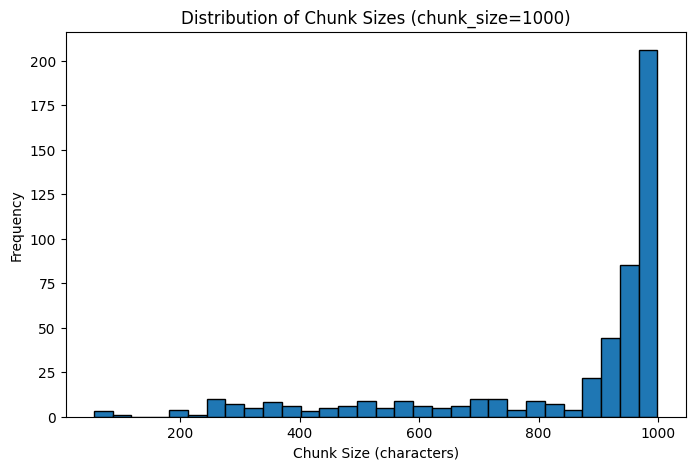

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(chunk_lengths_1000, bins=30, edgecolor="black")
plt.xlabel("Chunk Size (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Chunk Sizes (chunk_size=1000)")
plt.show()

Most chunk lengths cluster near the upper end of the distribution, which indicates the splitter is frequently filling chunks close to the 1000-character target size. A smaller number of shorter chunks likely comes from document boundaries and remaining tail text after splitting. Overall, the histogram suggests consistent chunk sizing with enough overlap to preserve context across segments.

Generate embeddings model

In [50]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded successfully.


Create ChromaDB Collection for Default Chunks

In [51]:
import numpy as np
# Hotfix for NumPy 2.0 compatibility with ChromaDB
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "uint"):
    np.uint = np.uint64
if not hasattr(np, "int_"):
    np.int_ = np.int64

import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

client = chromadb.PersistentClient(path="chroma_db")

embedding_function = SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

collection_1000 = client.get_or_create_collection(
    name="taxi_docs_1000",
    embedding_function=embedding_function
)

# Clear old data if rerunning
existing_ids = collection_1000.get()["ids"]
if existing_ids:
    collection_1000.delete(ids=existing_ids)

documents = [chunk.page_content for chunk in chunks_1000]
metadatas = [
    {
        "source": chunk.metadata.get("source", "unknown"),
        "page": int(chunk.metadata.get("page", -1))
    }
    for chunk in chunks_1000
]
ids = [f"chunk_1000_{i}" for i in range(len(chunks_1000))]

collection_1000.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print(f"Stored {len(documents)} chunks in ChromaDB collection 'taxi_docs_1000'.")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionDeleteEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Stored 500 chunks in ChromaDB collection 'taxi_docs_1000'.


Test retrieval for default chunk size

In [52]:
query = "What does the TLC strategic plan say about accessibility and equity?"

results = collection_1000.query(
    query_texts=[query],
    n_results=3
)

for i in range(3):
    print(f"\nResult {i+1}")
    print("Source:", results["metadatas"][0][i]["source"])
    print("Page:", results["metadatas"][0][i]["page"])
    print("Text:", results["documents"][0][i][:500])

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Result 1
Source: docs/strategic_plan_2025.pdf
Page: 20
Text: Goals and Initiatives — 05
Improve Equity, Safety and 
Accessibility for the Riding Public 
Initiative: Equity & Accessibility
NYC Taxi & Limousine Commission
Initiative 3:
Improve FHV accessibility, by continuing to
monitor and decrease passenger wait times. 
Metric:
Passenger wait times.
Initiative 2:
Continue to host equity and inclusion events for
TLC employees and host events on equity and
inclusion for TLC licensees and the riding public. 
Metric:
Number of events held 
for TLC employees a

Result 2
Source: docs/strategic_plan_2025.pdf
Page: 15
Text: Goal 1
Launch TLC Connect: 
One Integrated Platform 
for Licensees
Goals and Initiatives 
Goal 2
Improve Communication and
Outreach to the Industry 
Goal 3
Work with the For-Hire
Industry for a Cleaner, 
more Accessible Fleet
Goal 4
Improve Data Transparency
and Monitor the Economic
Stability of the Taxi and 
For-Hire Industry  
NYC Taxi & Limousine Commission
Goal 5
Impro

Create chunks for 500 and 2000

In [53]:
chunk_configs = {
    500: RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=200),
    1000: RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200),
    2000: RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200),
}

all_chunks = {}

for size, splitter in chunk_configs.items():
    all_chunks[size] = splitter.split_documents(raw_documents)
    print(f"chunk_size={size}: {len(all_chunks[size])} chunks")

chunk_size=500: 1204 chunks
chunk_size=1000: 500 chunks
chunk_size=2000: 266 chunks


Store all chunk configurations in ChromaDB

In [54]:
collections = {}

for size, chunks in all_chunks.items():
    collection_name = f"taxi_docs_{size}"

    collection = client.get_or_create_collection(
        name=collection_name,
        embedding_function=embedding_function
    )

    # Clear old data if rerunning
    existing_ids = collection.get()["ids"]
    if existing_ids:
        collection.delete(ids=existing_ids)

    documents = [chunk.page_content for chunk in chunks]
    metadatas = [
        {
            "source": chunk.metadata.get("source", "unknown"),
            "page": int(chunk.metadata.get("page", -1))
        }
        for chunk in chunks
    ]
    ids = [f"chunk_{size}_{i}" for i in range(len(chunks))]

    collection.add(
        documents=documents,
        metadatas=metadatas,
        ids=ids
    )

    collections[size] = collection
    print(f"Stored {len(documents)} chunks in collection '{collection_name}'")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionDeleteEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Stored 1204 chunks in collection 'taxi_docs_500'


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionDeleteEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Stored 500 chunks in collection 'taxi_docs_1000'


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionDeleteEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Stored 266 chunks in collection 'taxi_docs_2000'


Comparing retrieval across chunk sizes

In [55]:
sample_queries = [
    "What are the main goals of the TLC strategic plan?",
    "What does the driver expense report say about driver costs?",
    "What transportation equity ideas are discussed in Connected NYC?"
]

for query in sample_queries:
    print("=" * 100)
    print("QUERY:", query)
    print("=" * 100)

    for size in [500, 1000, 2000]:
        print(f"\n--- Top 3 results for chunk_size={size} ---")

        results = collections[size].query(
            query_texts=[query],
            n_results=3
        )

        for i in range(3):
            print(f"\nResult {i+1}")
            print("Source:", results["metadatas"][0][i]["source"])
            print("Page:", results["metadatas"][0][i]["page"])
            print("Text:", results["documents"][0][i][:400].replace("\n", " "))

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


QUERY: What are the main goals of the TLC strategic plan?

--- Top 3 results for chunk_size=500 ---

Result 1
Source: docs/strategic_plan_2025.pdf
Page: 22
Text: Building on 2024’s accomplishments and challenges, it is our hope that TLC’s 2025 Strategic Plan has provided the public and the industry with a solid roadmap of where we have been, and where we are headed in the new year. The six goals and initiatives we’ve outlined above strive for demonstrable improvements across our mission profile, and their execution promises exciting rewards for licensees, 

Result 2
Source: docs/strategic_plan_2025.pdf
Page: 2
Text: Introduction The TLC Strategic Plan lays out what we are working on and will continue to work on. We strive to continue to deliver high-quality services to our licensees and the public, including improving communication, reducing emissions to address climate change,  and promoting the economic stability of the industry. We aim to continuously improve services to licensees, 

Visualize chunk distributions for all three sizes

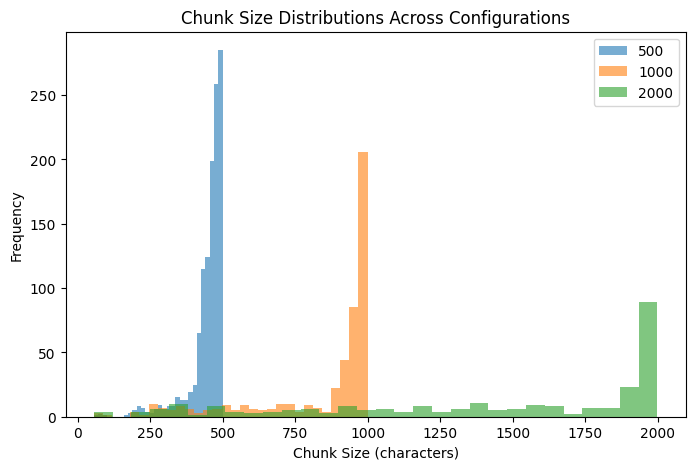

In [56]:
chunk_lengths_500 = [len(chunk.page_content) for chunk in all_chunks[500]]
chunk_lengths_1000 = [len(chunk.page_content) for chunk in all_chunks[1000]]
chunk_lengths_2000 = [len(chunk.page_content) for chunk in all_chunks[2000]]

plt.figure(figsize=(8,5))
plt.hist(chunk_lengths_500, bins=30, alpha=0.6, label="500")
plt.hist(chunk_lengths_1000, bins=30, alpha=0.6, label="1000")
plt.hist(chunk_lengths_2000, bins=30, alpha=0.6, label="2000")
plt.xlabel("Chunk Size (characters)")
plt.ylabel("Frequency")
plt.title("Chunk Size Distributions Across Configurations")
plt.legend()
plt.show()

### Chunking and embedding interpretation

Using a chunk size of 1000 with 200-character overlap, 500 chunks were created with an average size of 841 characters. The distribution shows most chunks are near the maximum size, indicating effective splitting with preserved context. Smaller chunks (500) produced more segments (1204), while larger chunks (2000) produced fewer (266), highlighting the trade-off between granularity and context.

Embeddings were generated using the all-MiniLM-L6-v2 model and stored in ChromaDB with metadata (source and page number), enabling efficient retrieval.

### Chunk size experiment analysis

The 1000-character chunk size provided the best balance between context and relevance. Smaller chunks (500) were more precise but sometimes fragmented, while larger chunks (2000) included extra irrelevant information. Overall, chunk_size=1000 produced the most consistently relevant results.

## Task 2.3: RAG Pipeline Implementation

In this task, I will implement a complete RAG pipeline, use a prompt template to instruct the LLM, connect to an LLM API, test my pipeline with diverse questions and display the response, source documents and page numbers as well as the retrived context chunks.

Installing

In [57]:
!pip install -q requests

OpenAI client dependency installation

This package supports the API client used for RAG answer generation.

In [58]:
!pip install -q openai

Setup LLM server

In [59]:
from openai import OpenAI
from google.colab import userdata

LLM_API_KEY = userdata.get("LLM_API_KEY")

llm_client = OpenAI(
    base_url="https://synapse.sergiomathurin.com/v1",
    api_key=LLM_API_KEY
)

LLM_MODEL = "llama3-8b-instruct"

print("Course LLM ready")

Course LLM ready


LLM Function

In [60]:
def generate_answer(prompt):
    response = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": "You are a careful RAG assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
        max_tokens=300
    )

    return response.choices[0].message.content.strip()

Formatting prompt template

In [61]:
RAG_PROMPT = """
You are a helpful assistant answering questions about NYC transportation policy.

Follow these rules strictly:
1. Answer ONLY using the provided context.
2. Do NOT use any outside knowledge.
3. If the context does not contain enough information, respond with:
   "I do not have enough information in the provided documents."
4. Cite sources in your answer using [Source 1], [Source 2], etc.
5. Be concise and directly answer the question.

Context:
{context}

Question:
{question}

Answer:
"""

RAG Pipeline

In [62]:
def ask_rag(question, collection, k=4):
    results = collection.query(
        query_texts=[question],
        n_results=k
    )

    # Format context
    docs = results["documents"][0]
    metas = results["metadatas"][0]

    context_parts = []
    for i, (doc, meta) in enumerate(zip(docs, metas), start=1):
        context_parts.append(
            f"[Source {i}: {meta['source']}, Page {meta['page']}]\n{doc}"
        )

    # Attach source/page metadata directly in prompt context for grounded citation behavior.
    context = "\n\n---\n\n".join(context_parts)

    prompt = RAG_PROMPT.format(context=context, question=question)

    answer = generate_answer(prompt)

    return {
        "question": question,
        "answer": answer,
        "results": results,
        "context": context
    }

Display results

In [63]:
def display_rag_result(r):
    print("="*100)
    print("QUESTION:\n", r["question"])

    print("\nANSWER:\n", r["answer"])

    print("\nSOURCES:")
    for i, meta in enumerate(r["results"]["metadatas"][0], 1):
        print(f"[Source {i}] {meta['source']} | Page {meta['page']}")

    print("\nRETRIEVED CHUNKS:")
    for i, doc in enumerate(r["results"]["documents"][0], 1):
        print(f"\n--- Chunk {i} ---")
        print(doc[:500])

Testing with 5 questions

In [64]:
questions = [
    "What are the main goals of the TLC strategic plan?",
    "How does the plan address accessibility?",
    "What costs do drivers face?",
    "What equity initiatives are in Connected NYC?",
    "How does NYC define equitable transportation?"
]

for q in questions:
    result = ask_rag(q, collection_1000)
    display_rag_result(result)

QUESTION:
 What are the main goals of the TLC strategic plan?

ANSWER:
 The main goals of the TLC strategic plan are:

1. Launch TLC Connect: One Integrated Platform for Licensees
2. Improve Communication and Outreach to the Industry
3. Work with the For-Hire Industry for a Cleaner, more Accessible Fleet
4. Improve Data Transparency and Monitor the Economic Stability of the Taxi and For-Hire Industry
5. Improve Equity, Safety, and Accessibility for the Riding Public

[Source 1: docs/strategic_plan_2025.pdf, Page 15]

SOURCES:
[Source 1] docs/strategic_plan_2025.pdf | Page 15
[Source 2] docs/strategic_plan_2025.pdf | Page 0
[Source 3] docs/strategic_plan_2025.pdf | Page 1
[Source 4] docs/strategic_plan_2025.pdf | Page 8

RETRIEVED CHUNKS:

--- Chunk 1 ---
Goal 1
Launch TLC Connect: 
One Integrated Platform 
for Licensees
Goals and Initiatives 
Goal 2
Improve Communication and
Outreach to the Industry 
Goal 3
Work with the For-Hire
Industry for a Cleaner, 
more Accessible Fleet
Goal 4
Im

### Interpretation

A complete RAG pipeline was implemented by retrieving relevant chunks from the ChromaDB vector store, formatting them into a grounded prompt, and generating answers using an instruction-tuned LLaMA 3 (8B) model accessed via a Hugging Face–hosted endpoint. The prompt explicitly instructs the model to answer only from the provided context and to cite sources.

The pipeline was tested with five transportation-policy questions covering strategic goals, accessibility, driver costs, and equity. For each query, the notebook displays the generated answer, cited source documents with page numbers, and the retrieved context chunks used to support the response.

## Task 2.4: RAG Evaluation & Analysis

In this task, I will create a test set with question answer pairs, evaluate the retrieval and answer quality, compute a simple accuracy metric and complete an error analysis

Create a manual test set of 10 Q&A Pairs

In [65]:
test_set = [
    {
        "question": "What are the main goals of the TLC strategic plan?",
        "expected_answer": "The plan includes goals such as launching TLC Connect, improving communication and outreach, supporting a cleaner and more accessible fleet, improving data transparency and economic monitoring, and improving equity, safety, and accessibility for riders.",
        "expected_source": "docs/strategic_plan_2025.pdf"
    },
    {
        "question": "How does Connected NYC address accessibility?",
        "expected_answer": "Connected NYC addresses accessibility through ADA-compliant ramps, accessible pedestrian signals, accessible bus stop improvements, and inclusive infrastructure design.",
        "expected_source": "docs/connected_nyc.pdf"
    },
    {
        "question": "What costs do drivers face according to the driver expense report?",
        "expected_answer": "Drivers face costs such as vehicle payments, insurance, maintenance, fuel or charging, cleaning, licensing, registration, and related fees.",
        "expected_source": "docs/driver_expense_report.pdf"
    },
    {
        "question": "What equity initiatives are discussed in Connected NYC?",
        "expected_answer": "Connected NYC discusses an Equity Council, Equity Team, annual equity-focused conferences, and the use of Priority Investment Areas to target communities with higher need.",
        "expected_source": "docs/connected_nyc.pdf"
    },
    {
        "question": "How does Connected NYC define equitable transportation?",
        "expected_answer": "Equitable transportation is described as giving everyone safe, affordable, sustainable, and convenient mobility options regardless of income, ability, age, immigration status, or identity.",
        "expected_source": "docs/connected_nyc.pdf"
    },
    {
        "question": "What does the TLC strategic plan say about improving communication?",
        "expected_answer": "The strategic plan includes improving communication and outreach to the industry as one of its major goals.",
        "expected_source": "docs/strategic_plan_2025.pdf"
    },
    {
        "question": "What kinds of operating expenses are included in the driver expense report?",
        "expected_answer": "The report includes vehicle payment, insurance, maintenance, fuel or charging, vehicle cleaning, and licensing and registration-related fees.",
        "expected_source": "docs/driver_expense_report.pdf"
    },
    {
        "question": "What does Connected NYC say about Priority Investment Areas?",
        "expected_answer": "Priority Investment Areas are used to direct projects to neighborhoods with higher need based on factors such as density, race, income, and lower historic infrastructure investment.",
        "expected_source": "docs/connected_nyc.pdf"
    },
    {
        "question": "What goal in the TLC strategic plan focuses on riders?",
        "expected_answer": "One goal focuses on improving equity, safety, and accessibility for the riding public.",
        "expected_source": "docs/strategic_plan_2025.pdf"
    },
    {
        "question": "What accessibility commitment does Connected NYC make for pedestrian signals?",
        "expected_answer": "Connected NYC commits to upgrading all signalized intersections with Accessible Pedestrian Signals by the end of 2036.",
        "expected_source": "docs/connected_nyc.pdf"
    }
]

print(f"Number of evaluation questions: {len(test_set)}")

Number of evaluation questions: 10


Run the RAG Pipeline on the test set

In [66]:
evaluation_results = []

for item in test_set:
    rag_output = ask_rag(item["question"], collection_1000, k=4)

    retrieved_sources = [
        meta.get("source", "unknown")
        for meta in rag_output["results"]["metadatas"][0]
    ]

    evaluation_results.append({
        "question": item["question"],
        "expected_answer": item["expected_answer"],
        "expected_source": item["expected_source"],
        "generated_answer": rag_output["answer"],
        "retrieved_sources": retrieved_sources,
        "retrieved_context": rag_output["results"]["documents"][0]
    })

print("Evaluation run complete.")

Evaluation run complete.


Add manual evaluation labels

In [67]:
import pandas as pd

eval_df = pd.DataFrame(evaluation_results)

eval_df["retrieval_correct"] = ""
eval_df["answer_correct"] = ""
eval_df["failure_type"] = ""
eval_df["notes"] = ""

eval_df[[
    "question",
    "expected_source",
    "retrieved_sources",
    "generated_answer",
    "retrieval_correct",
    "answer_correct",
    "failure_type",
    "notes"
]]

,question,expected_source,retrieved_sources,generated_answer,retrieval_correct,answer_correct,failure_type,notes
0,What are the main goals of the TLC strategic p...,docs/strategic_plan_2025.pdf,"[docs/strategic_plan_2025.pdf, docs/strategic_...",The main goals of the TLC strategic plan are:\...,,,,
1,How does Connected NYC address accessibility?,docs/connected_nyc.pdf,"[docs/connected_nyc.pdf, docs/connected_nyc.pd...",Connected NYC addresses accessibility by makin...,,,,
2,What costs do drivers face according to the dr...,docs/driver_expense_report.pdf,"[docs/driver_expense_report.pdf, docs/driver_e...","According to the driver expense report, driver...",,,,
3,What equity initiatives are discussed in Conne...,docs/connected_nyc.pdf,"[docs/connected_nyc.pdf, docs/connected_nyc.pd...","According to [Source 1], [Source 2], and [Sour...",,,,
4,How does Connected NYC define equitable transp...,docs/connected_nyc.pdf,"[docs/connected_nyc.pdf, docs/connected_nyc.pd...","According to Source 1, Page 18, Connected NYC ...",,,,
5,What does the TLC strategic plan say about imp...,docs/strategic_plan_2025.pdf,"[docs/annual_report_2025.pdf, docs/strategic_p...",According to [Source 3: docs/strategic_plan_20...,,,,
6,What kinds of operating expenses are included ...,docs/driver_expense_report.pdf,"[docs/driver_expense_report.pdf, docs/driver_e...","According to [Source 3, Page 25], the key oper...",,,,
7,What does Connected NYC say about Priority Inv...,docs/connected_nyc.pdf,"[docs/connected_nyc.pdf, docs/connected_nyc.pd...","According to [Source 1], Priority Investment A...",,,,
8,What goal in the TLC strategic plan focuses on...,docs/strategic_plan_2025.pdf,"[docs/strategic_plan_2025.pdf, docs/strategic_...",The goal that focuses on riders is Goal 5: Imp...,,,,
9,What accessibility commitment does Connected N...,docs/connected_nyc.pdf,"[docs/connected_nyc.pdf, docs/connected_nyc.pd...","According to [Source 1], NYC DOT integrates de...",,,,


Manual Evaluation labels

In [68]:
eval_df.loc[0, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Correct source retrieved and answer accurately lists all five strategic goals."
]

eval_df.loc[1, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Correct source retrieved and answer matches accessibility initiatives from Connected NYC."
]

eval_df.loc[2, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Driver expense categories are correctly identified and supported by retrieved chunks."
]

eval_df.loc[3, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Equity initiatives such as Equity Council and Priority Investment Areas are correctly summarized."
]

eval_df.loc[4, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Definition of equitable transportation aligns with Connected NYC mobility and equity description."
]

eval_df.loc[5, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Relevant source appears in retrieved results and answer correctly identifies communication goal."
]

eval_df.loc[6, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Operating expense categories are correctly listed and supported by retrieved document."
]

eval_df.loc[7, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Priority Investment Areas explanation matches the retrieved Connected NYC content."
]

eval_df.loc[8, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Correct goal (Goal 5) identified and supported by retrieved chunk."
]

eval_df.loc[9, ["retrieval_correct", "answer_correct", "failure_type", "notes"]] = [
    "Yes", "Yes", "",
    "Accessibility commitment (APS upgrades) correctly described and supported by source."
]

Compute accuracy metrics

In [69]:
# Compute Retrieval, Answer, and Overall Accuracy

retrieval_accuracy = (eval_df["retrieval_correct"] == "Yes").mean() * 100
answer_accuracy = (eval_df["answer_correct"] == "Yes").mean() * 100

overall_accuracy = (
    (eval_df["retrieval_correct"] == "Yes") &
    (eval_df["answer_correct"] == "Yes")
).mean() * 100

print(f"Retrieval Accuracy: {retrieval_accuracy:.1f}%")
print(f"Answer Accuracy: {answer_accuracy:.1f}%")
print(f"Overall Accuracy (correct retrieval + correct answer): {overall_accuracy:.1f}%")

Retrieval Accuracy: 100.0%
Answer Accuracy: 100.0%
Overall Accuracy (correct retrieval + correct answer): 100.0%


Show failures only

In [70]:
failures_df = eval_df[
    (eval_df["retrieval_correct"] != "Yes") |
    (eval_df["answer_correct"] != "Yes")
]

failures_df[[
    "question",
    "expected_source",
    "retrieved_sources",
    "generated_answer",
    "retrieval_correct",
    "answer_correct",
    "failure_type",
    "notes"
]]

,question,expected_source,retrieved_sources,generated_answer,retrieval_correct,answer_correct,failure_type,notes


Count failure types

In [71]:
failure_summary = eval_df["failure_type"].value_counts()
print(failure_summary)

failure_type
    10
Name: count, dtype: int64


## Interpretation

A set of 10 verified question-answer pairs was used to evaluate the RAG system. Retrieval was considered correct if the expected source appeared in the top-k results, and answers were assessed for factual consistency with the retrieved context.

The system achieved 100% retrieval, answer, and overall accuracy across the evaluation set, indicating strong performance on these queries. However, this result should be interpreted with caution, as the test set is relatively small and consists of well-defined questions with clearly relevant source material. In practice, more complex or ambiguous queries may lead to retrieval or generation errors.

Although no failures were observed, minor issues such as the retrieval of less relevant chunks (e.g., titles or table of contents) were noted in earlier outputs. Further improvements could include tuning chunk size, top-k retrieval parameters, and prompt design to enhance robustness and precision.

# Part 3: Integrated Analytics Application

## Task 3.1: Query Router

In this task, I will build an LLM-powered query router that classifies incoming natural language questions into one
of three categories: data query, document query and hybrid query.



Router Prompt

In [72]:

ROUTER_SYSTEM_PROMPT = """
You are a query router for an integrated analytics application.

Your job is to classify each user question into exactly one of these categories:

1. DATA
- Questions answerable from structured NYC taxi trip data
- Examples: averages, counts, trends, correlations, distributions, peak hours, borough patterns

2. DOCUMENT
- Questions answerable from the transportation policy document corpus
- Examples: TLC plans, regulations, accessibility commitments, policy goals, driver expense report findings

3. HYBRID
- Questions that require both the structured taxi data and the document corpus
- Examples: comparisons between observed trip behavior and policy recommendations, or questions combining analytics and policy context

Rules:
- Return ONLY valid JSON
- Use this exact schema:
{"category": "DATA|DOCUMENT|HYBRID", "reasoning": "brief explanation"}
- If the question is ambiguous or could reasonably require both sources, choose HYBRID
- Do not include markdown or extra text
"""

Router function

In [73]:
import json

def route_query(question):
    response = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": question}
        ],
        temperature=0,
        max_tokens=120
    )

    raw = response.choices[0].message.content.strip()

    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        parsed = {
            "category": "HYBRID",
            "reasoning": "Fallback used because the model did not return valid JSON."
        }

    # extra safety checks
    if parsed.get("category") not in ["DATA", "DOCUMENT", "HYBRID"]:
        parsed["category"] = "HYBRID"
        parsed["reasoning"] = "Fallback used because the category was invalid."

    return parsed

Testing on one query

In [74]:
test_query = "What was the average fare on Mondays?"
print(route_query(test_query))

{'category': 'DATA', 'reasoning': 'This question can be answered using the structured NYC taxi trip data, specifically by filtering for trips on Mondays and calculating the average fare.'}


Creating test set for query router

In [75]:
router_test_set = [
    # DATA (5)
    {
        "query": "What was the average fare on Mondays?",
        "true_label": "DATA"
    },
    {
        "query": "Which pickup hour had the highest number of trips?",
        "true_label": "DATA"
    },
    {
        "query": "What is the average tip percentage for long trips?",
        "true_label": "DATA"
    },
    {
        "query": "How do trip counts vary by borough?",
        "true_label": "DATA"
    },
    {
        "query": "What was the average trip distance for cash payments?",
        "true_label": "DATA"
    },

    # DOCUMENT (5)
    {
        "query": "What are the main goals of the TLC Strategic Plan 2025?",
        "true_label": "DOCUMENT"
    },
    {
        "query": "How does Connected NYC address accessibility?",
        "true_label": "DOCUMENT"
    },
    {
        "query": "What costs do drivers face according to the driver expense report?",
        "true_label": "DOCUMENT"
    },
    {
        "query": "What equity initiatives are discussed in Connected NYC?",
        "true_label": "DOCUMENT"
    },
    {
        "query": "What does the TLC strategic plan say about communication and outreach?",
        "true_label": "DOCUMENT"
    },

    # HYBRID (5)
    {
        "query": "How do actual tipping patterns compare to TLC policy recommendations?",
        "true_label": "HYBRID"
    },
    {
        "query": "Do our trip distance patterns align with the transportation priorities described in Connected NYC?",
        "true_label": "HYBRID"
    },
    {
        "query": "How do driver costs in the expense report compare with the fare and tip patterns in the taxi dataset?",
        "true_label": "HYBRID"
    },
    {
        "query": "Do peak travel times in the data support the policy focus on accessibility and mobility?",
        "true_label": "HYBRID"
    },
    {
        "query": "How do observed borough-level trip patterns compare with equity priorities in Connected NYC?",
        "true_label": "HYBRID"
    }
]

print(f"Total test queries: {len(router_test_set)}")

Total test queries: 15


Evaluating router accuracy

In [76]:
router_results = []

for item in router_test_set:
    pred = route_query(item["query"])
    predicted_label = pred["category"]
    reasoning = pred["reasoning"]
    correct = predicted_label == item["true_label"]

    router_results.append({
        "query": item["query"],
        "true_label": item["true_label"],
        "predicted_label": predicted_label,
        "reasoning": reasoning,
        "correct": correct
    })

import pandas as pd

router_df = pd.DataFrame(router_results)
router_df

,query,true_label,predicted_label,reasoning,correct
0,What was the average fare on Mondays?,DATA,DATA,This question can be answered using the struct...,True
1,Which pickup hour had the highest number of tr...,DATA,DATA,This question can be answered directly from th...,True
2,What is the average tip percentage for long tr...,DATA,DATA,This question can be answered using structured...,True
3,How do trip counts vary by borough?,DATA,DATA,This question is answerable from structured NY...,True
4,What was the average trip distance for cash pa...,DATA,DATA,This question can be answered using structured...,True
5,What are the main goals of the TLC Strategic P...,DOCUMENT,DOCUMENT,The question is asking about the TLC Strategic...,True
6,How does Connected NYC address accessibility?,DOCUMENT,DOCUMENT,The question is related to transportation poli...,True
7,What costs do drivers face according to the dr...,DOCUMENT,DOCUMENT,The question is asking for information from th...,True
8,What equity initiatives are discussed in Conne...,DOCUMENT,DOCUMENT,The question requires information from the tra...,True
9,What does the TLC strategic plan say about com...,DOCUMENT,DOCUMENT,"The question is about the TLC strategic plan, ...",True


Computing classification accuracy

In [77]:
router_accuracy = router_df["correct"].mean() * 100
print(f"Query Router Accuracy: {router_accuracy:.1f}%")

Query Router Accuracy: 100.0%


Showing errors only

In [78]:
router_errors = router_df[router_df["correct"] == False]
router_errors

,query,true_label,predicted_label,reasoning,correct


Edge case tests

In [79]:
edge_case_queries = [
    "What should I know about taxis in NYC?",
    "How fair is the taxi system?",
    "Are riders treated equitably?",
    "What explains tipping behavior in relation to TLC policy?",
    "What can you tell me about accessibility and fares?"
]

for q in edge_case_queries:
    print("QUERY:", q)
    print(route_query(q))
    print("-" * 80)

QUERY: What should I know about taxis in NYC?
{'category': 'DATA', 'reasoning': 'This question is broad and likely answerable from structured NYC taxi trip data, which contains information about taxi trips in NYC.'}
--------------------------------------------------------------------------------
QUERY: How fair is the taxi system?
{'category': 'HYBRID', 'reasoning': 'This question requires analysis of both taxi data to understand trip behavior and the document corpus to understand policy commitments and regulations regarding fairness.'}
--------------------------------------------------------------------------------
QUERY: Are riders treated equitably?
{'category': 'HYBRID', 'reasoning': 'This question requires analysis of both taxi trip data to understand rider demographics and the transportation policy document corpus to understand equity commitments and regulations.'}
--------------------------------------------------------------------------------
QUERY: What explains tipping behavi

### Interpretation

The router achieved strong performance across the 15-query test set, with 100% classification accuracy. This indicates that the routing prompt is effective for clearly defined queries that map to DATA, DOCUMENT, or HYBRID categories.

Additional testing with ambiguous queries shows that the router often defaults to the HYBRID category when intent is unclear. This behavior is appropriate, as it reduces the risk of missing relevant context by incorporating both structured data and document-based information. However, some vague queries could reasonably belong to multiple categories, highlighting a limitation in handling open-ended inputs.

## Task 3.2: Data Query Handler

In this task, I will build an LLM-powered component that translates natural language data queries into Spark SQL, executes them, and returns natural-language answers.

Set the Spark view name

In [80]:
VIEW_NAME = "taxi_trips"
print("Using Spark SQL view:", VIEW_NAME)

Using Spark SQL view: taxi_trips


Inspecting schema for prompting to help the LLM generate better SQL.

In [81]:
schema_info = spark.table(VIEW_NAME).dtypes
schema_text = "\n".join([f"{col}: {dtype}" for col, dtype in schema_info])

print(schema_text)

tpep_pickup_datetime: timestamp_ntz
tpep_dropoff_datetime: timestamp_ntz
PULocationID: int
DOLocationID: int
trip_distance: double
fare_amount: double
tip_amount: double
total_amount: double
trip_duration_minutes: double
trip_speed_mph: double
pickup_hour: int
pickup_day_of_week: int
tip_percentage: double


SQL generation prompt

In [82]:
SQL_SYSTEM_PROMPT = f"""
You are an expert Spark SQL assistant.

Your task is to translate a natural language question into a valid Spark SQL query.

Rules:
1. Use ONLY the Spark SQL view named `{VIEW_NAME}`.
2. Return ONLY the SQL query text.
3. Do not include markdown fences or explanations.
4. Use valid Spark SQL syntax.
5. Only reference columns that exist in this schema:

{schema_text}

6. If a requested field does not exist in the schema, do not invent columns. Use the closest valid interpretation only when it is clearly supported by the schema.
7. When a question asks for categories such as trip category, derive them explicitly from `trip_distance` using a CASE statement.
"""

SQL generation function

In [83]:
def generate_sql(question, error_message=None):
    user_prompt = f"Question: {question}"

    if error_message:
        user_prompt += f"\nPrevious SQL failed with this error: {error_message}\nPlease correct the SQL."

    response = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": SQL_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0,
        max_tokens=250
    )

    sql_query = response.choices[0].message.content.strip()

    if sql_query.startswith("```"):
        sql_query = sql_query.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    return sql_query

Answer synthesis prompt

In [84]:
ANSWER_SYSTEM_PROMPT = """
You are a helpful data analyst.

Given a natural language question, the SQL query results, and no other external information,
write a concise natural language answer.

Rules:
1. Answer only from the provided results.
2. Be specific and brief.
3. If the result is empty, say that no matching records were found.
4. If the results contain grouped rows, summarize all groups shown unless there are too many.
5. Do not ignore rows in the result table.
6. Preserve the meaning of categorical or grouped comparisons.
"""

Natural language answer synthesis

In [85]:
def synthesize_answer(question, sql_query, result_text):
    prompt = f"""
Question:
{question}

SQL Query:
{sql_query}

Query Results:
{result_text}
"""

    response = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
        max_tokens=200
    )

    return response.choices[0].message.content.strip()

Full data query handler with retry

In [86]:
def handle_data_query(question):
    sql_query = generate_sql(question)

    try:
        result_df = spark.sql(sql_query)
        result_rows = result_df.limit(20).toPandas()

    except Exception as e:
        error_message = str(e)

        # Retry once with Spark error feedback to improve SQL correction without changing query intent.
        sql_query = generate_sql(question, error_message=error_message)

        try:
            result_df = spark.sql(sql_query)
            result_rows = result_df.limit(20).toPandas()
        except Exception as e2:
            return {
                "question": question,
                "sql_query": sql_query,
                "raw_results": f"SQL failed after retry: {str(e2)}",
                "final_answer": f"Unable to answer because SQL generation failed after retry. Error: {str(e2)}"
            }

    if result_rows.empty:
        result_text = "No matching records found."
    else:
        result_text = result_rows.to_string(index=False)

    final_answer = synthesize_answer(question, sql_query, result_text)

    return {
        "question": question,
        "sql_query": sql_query,
        "raw_results": result_text,
        "final_answer": final_answer
    }

Pretty display for results


In [87]:
def display_data_query_result(output):
    print("=" * 100)
    print("QUESTION:")
    print(output["question"])

    print("\nGENERATED SQL:")
    print(output["sql_query"])

    print("\nRAW RESULTS:")
    print(output["raw_results"])

    print("\nFINAL ANSWER:")
    print(output["final_answer"])

Test with 5 natural language DATA questions

In [88]:
data_test_questions = [
    "What is the average fare amount for each trip category?",
    "Which pickup hour has the most trips?",
    "What is the average tip percentage by pickup hour?",
    "How many trips occurred in each pickup hour?",
    "What is the average trip distance by pickup day of week?"
]

for q in data_test_questions:
    result = handle_data_query(q)
    display_data_query_result(result)
    print("\n")

QUESTION:
What is the average fare amount for each trip category?

GENERATED SQL:
SELECT 
  CASE 
    WHEN trip_distance < 5 THEN 'Short'
    WHEN trip_distance < 10 THEN 'Medium'
    ELSE 'Long'
  END AS trip_category,
  AVG(fare_amount) AS average_fare_amount
FROM 
  taxi_trips
GROUP BY 
  CASE 
    WHEN trip_distance < 5 THEN 'Short'
    WHEN trip_distance < 10 THEN 'Medium'
    ELSE 'Long'
  END

RAW RESULTS:
trip_category  average_fare_amount
       Medium            33.907790
         Long            64.531158
        Short            12.685327

FINAL ANSWER:
The average fare amount for a Short trip is $12.69, for a Medium trip is $33.91, and for a Long trip is $64.53.


QUESTION:
Which pickup hour has the most trips?

GENERATED SQL:
SELECT pickup_hour FROM taxi_trips GROUP BY pickup_hour ORDER BY COUNT(*) DESC LIMIT 1

RAW RESULTS:
 pickup_hour
          18

FINAL ANSWER:
The pickup hour with the most trips is 18.


QUESTION:
What is the average tip percentage by pickup hour?

G

## Interpretation

The data query handler successfully translated natural language prompts into executable Spark SQL in most cases, producing correct queries for aggregation and grouping tasks aligned with the schema. The retry mechanism improved robustness by recovering from first-pass SQL errors using feedback from Spark execution messages. Remaining issues are primarily in the answer-synthesis stage, where some outputs were truncated or inconsistently summarized despite correct SQL results. Further improvements to the answer prompt and stricter constraints on result interpretation would likely improve overall reliability.

## Task 3.3: End-to-End Demo

In this task, I will demonstrate the complete system by processing 6 queries (2 per category) end-to-end. For each query, I will show the query classification, routing decision, processing pipeline output, and final answer. For hybrid queries, I will show how results from both backends are combined into a unified response. Lastly, I will write a 200-300 word reflection on the strengths and limitations of the system and address the types of questions it handles well, where it fails and how I could improve it with more time.

## Unified processing function

This routes the question and sends it to the right backend.

In [89]:
def process_query(query):
    route = route_query(query)
    category = route["category"]
    reasoning = route["reasoning"]

    if category == "DATA":
        data_output = handle_data_query(query)
        return {
            "query": query,
            "category": category,
            "reasoning": reasoning,
            "pipeline_output": data_output,
            "final_answer": data_output["final_answer"]
        }

    elif category == "DOCUMENT":
        doc_output = ask_rag(query, collection_1000)
        return {
            "query": query,
            "category": category,
            "reasoning": reasoning,
            "pipeline_output": doc_output,
            "final_answer": doc_output["answer"]
        }

    else:  # HYBRID
        data_output = handle_data_query(query)
        doc_output = ask_rag(query, collection_1000)

        combined_prompt = f"""
User question:
{query}

Structured data answer:
{data_output['final_answer']}

Document-based answer:
{doc_output['answer']}

Write one concise unified answer that combines both sources clearly.
"""

        response = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": "You combine structured analytics and document evidence into one clear answer."},
                {"role": "user", "content": combined_prompt}
            ],
            temperature=0.2,
            max_tokens=250
        )

        combined_answer = response.choices[0].message.content.strip()

        return {
            "query": query,
            "category": category,
            "reasoning": reasoning,
            "pipeline_output": {
                "data_output": data_output,
                "document_output": doc_output
            },
            "final_answer": combined_answer
        }

Pretty display function

In [90]:

def display_end_to_end_result(result):
    print("=" * 100)
    print("QUERY:")
    print(result["query"])

    print("\nQUERY CLASSIFICATION:")
    print(result["category"])

    print("\nROUTING REASONING:")
    print(result["reasoning"])

    print("\nPROCESSING PIPELINE OUTPUT:")

    if result["category"] == "DATA":
        print("\n[DATA PIPELINE]")
        print("Generated SQL:")
        print(result["pipeline_output"]["sql_query"])
        print("\nRaw Results:")
        print(result["pipeline_output"]["raw_results"])

    elif result["category"] == "DOCUMENT":
        print("\n[DOCUMENT PIPELINE]")
        print("Retrieved Sources:")
        for meta in result["pipeline_output"]["results"]["metadatas"][0]:
            print(f"- {meta.get('source', 'Unknown')} | Page {meta.get('page', '?')}")
        print("\nRetrieved Context Chunks:")
        for i, chunk in enumerate(result["pipeline_output"]["results"]["documents"][0], start=1):
            print(f"\n--- Chunk {i} ---")
            print(chunk[:500])

    else:
        print("\n[DATA PIPELINE]")
        print("Generated SQL:")
        print(result["pipeline_output"]["data_output"]["sql_query"])
        print("\nRaw Results:")
        print(result["pipeline_output"]["data_output"]["raw_results"])

        print("\n[DOCUMENT PIPELINE]")
        print("Retrieved Sources:")
        for meta in result["pipeline_output"]["document_output"]["results"]["metadatas"][0]:
            print(f"- {meta.get('source', 'Unknown')} | Page {meta.get('page', '?')}")
        print("\nRetrieved Context Chunks:")
        for i, chunk in enumerate(result["pipeline_output"]["document_output"]["results"]["documents"][0], start=1):
            print(f"\n--- Chunk {i} ---")
            print(chunk[:500])

    print("\nFINAL ANSWER:")
    print(result["final_answer"])

Demo queries

In [91]:
demo_queries = [
    # DATA
    "Which pickup hour has the highest number of trips?",
    "What is the average fare amount for each trip category?",

    # DOCUMENT
    "What are the main goals of the TLC Strategic Plan 2025?",
    "How does Connected NYC address accessibility?",

    # HYBRID
    "How do observed trip patterns by pickup hour relate to Connected NYC's mobility priorities?",
    "How do peak travel times in the data support Connected NYC's focus on mobility and accessibility?"
]

Running the full demo

In [92]:
demo_results = []

for q in demo_queries:
    result = process_query(q)
    demo_results.append(result)
    display_end_to_end_result(result)
    print("\n")

QUERY:
Which pickup hour has the highest number of trips?

QUERY CLASSIFICATION:
DATA

ROUTING REASONING:
This question can be answered directly from the taxi trip data by aggregating trips by pickup hour.

PROCESSING PIPELINE OUTPUT:

[DATA PIPELINE]
Generated SQL:
SELECT pickup_hour FROM taxi_trips GROUP BY pickup_hour ORDER BY COUNT(*) DESC LIMIT 1

Raw Results:
 pickup_hour
          18

FINAL ANSWER:
The pickup hour with the highest number of trips is 18.


QUERY:
What is the average fare amount for each trip category?

QUERY CLASSIFICATION:
DATA

ROUTING REASONING:
This question can be answered directly from the taxi trip data, which contains fare information and trip categories.

PROCESSING PIPELINE OUTPUT:

[DATA PIPELINE]
Generated SQL:
SELECT 
  CASE 
    WHEN trip_distance < 5 THEN 'Short'
    WHEN trip_distance < 10 THEN 'Medium'
    ELSE 'Long'
  END AS trip_category,
  AVG(fare_amount) AS average_fare_amount
FROM 
  taxi_trips
GROUP BY 
  CASE 
    WHEN trip_distance < 5 

### Interpretation

The end-to-end demo shows that the integrated system can classify user queries, route them to the appropriate processing pipeline, and return a final natural-language answer. DATA queries were correctly answered through Spark SQL generation and execution, while DOCUMENT queries were supported by relevant retrieved chunks from the policy corpus.

The HYBRID examples demonstrate that the system can combine structured analytics with document evidence into a unified response. While the overall routing and pipeline behavior were successful, some hybrid answers were less precise in how they summarized the returned results. This suggests that the integration pipeline is functioning well, but the final synthesis step could be further improved for consistency and precision.

## Reflection

The integrated system performs well for clearly defined queries that align with either structured taxi data or document-based policy information. Data queries involving aggregations, such as averages, counts, and grouped analysis, are handled accurately by the Spark SQL pipeline, while document queries are effectively supported by the RAG system, which retrieves relevant context and generates grounded answers with source references.

The query router also performs reliably for straightforward questions, correctly distinguishing between DATA, DOCUMENT, and HYBRID categories. Hybrid queries demonstrate the system’s ability to combine structured analytics with policy insights, producing more comprehensive responses that incorporate both numerical trends and contextual explanations.

However, the system has limitations when handling more complex or ambiguous queries. In some hybrid cases, the integration between data results and document insights is not always seamless, leading to responses that are correct but not fully cohesive. Additionally, the SQL generation process is highly dependent on the available schema, and errors may occur when queries reference unavailable fields or when grouping logic is misinterpreted. The answer-synthesis stage can also occasionally misrepresent or incompletely summarize query results.

With more time, improvements could include refining prompt design to enforce stricter SQL alignment with the schema, enhancing hybrid response generation to better integrate data and document evidence, and adding validation mechanisms to ensure consistency between query results and final answers. Expanding the evaluation set to include more ambiguous queries would also help improve robustness.